# Option backtest with assumptions
Assumptions:
- Delta range (0.25, 0.4)
- Premium: 6%
- ES target: 1%
- Roll over min: 15 days
- Budget per position: $250,000,0
- Positions: 20
- dtm range: (15, 30)
- momentum window: 30
- zscore_window: 15
- gamma range: (0.001, 0.015)

In [1]:
import pandas as pd

In [2]:
results = pd.read_csv('covered_call_backtest_results.csv')

In [3]:
results.head()

,Symbol,Entry Date,Exit Date,Entry Price,Exit Price,Stock PnL,Option PnL,Total PnL,Return,Reason
0,ISRG,2020-01-23,2020-01-24,615.00,589.20,-10474.80,2645.476732,-7829.323268,-0.031356,Signal Exit
1,CMG,2020-01-23,2020-01-24,879.84,869.71,-2876.92,993.368526,-1883.551474,-0.007538,Signal Exit
2,CHTR,2020-01-23,2020-01-24,513.14,504.67,-4124.89,1322.865015,-2802.024985,-0.011213,Signal Exit
3,LRCX,2020-01-23,2020-01-27,312.42,293.79,-14904.00,3474.600677,-11429.399323,-0.045729,Signal Exit
4,BLK,2020-01-23,2020-01-27,541.94,523.81,-8357.93,2570.679924,-5787.250076,-0.023164,Signal Exit


In [5]:
print(f"Avg PnL: ${results['Total PnL'].mean():,.2f}")
print(f"Avg Return: {results['Return'].mean()*100:.2f}%")
print(f"Win Rate: {(results['Total PnL'] > 0).mean()*100:.2f}%")
print(f"Total PnL: ${results['Total PnL'].sum():,.2f}")
print(f"Max PnL: ${results['Total PnL'].max():,.2f}")
print(f"Min PnL (Max Loss): ${results['Total PnL'].min():,.2f}")
print(f"Std Dev PnL: ${results['Total PnL'].std():,.2f}")
print(f"Number of Trades: {len(results)}")


Avg PnL: $1,554.94
Avg Return: 0.62%
Win Rate: 40.02%
Total PnL: $5,661,543.37
Max PnL: $101,256.04
Min PnL (Max Loss): $-230,454.82
Std Dev PnL: $13,642.21
Number of Trades: 3641


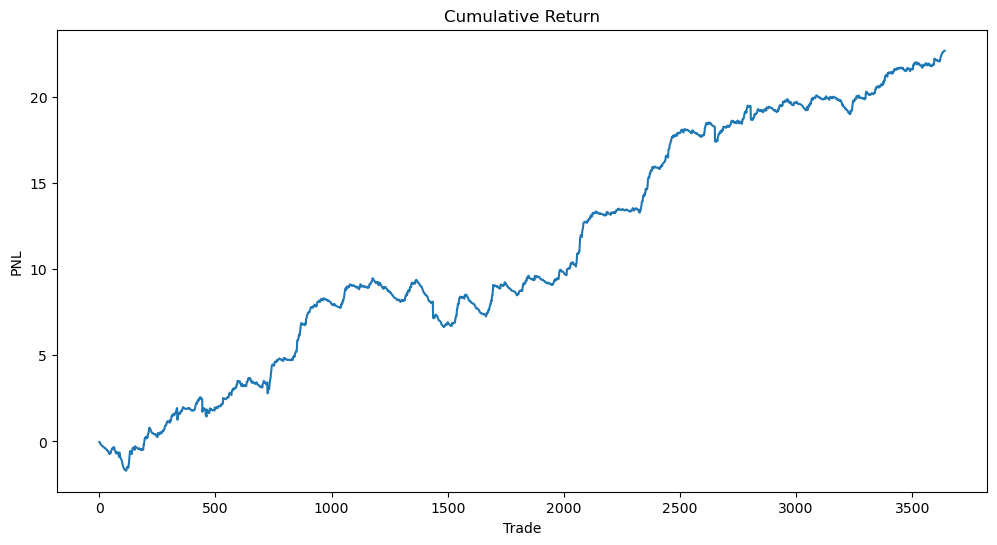

In [6]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
# plot the cumsum PNL
plt.plot(results['Return'].cumsum())
plt.title('Cumulative Return')
plt.xlabel('Trade')
plt.ylabel('PNL')
plt.show()